In [1]:
%matplotlib widget

# 3D Forward with dipping boundary

In [2]:
# Script to create synthetic 3D data

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed
import sys
sys.path.insert(1, 'src')

In [116]:
# 0. Define instrument settings

height = 0.15
frequency = 9000
n_workers = 20

# Define angles to test

alpha = np.arange(0,10)
alpha_rad = np.deg2rad(alpha)

alp = alpha_rad[-5]
pos = np.arange(0,30)
h1 = np.ones_like(pos, dtype=float)
h1[:15] = h1[:15] - np.flip(pos[:15]) * np.tan(alp)
h1[14:] = h1[14:] + pos[:16]* np.tan(alp)

# 1. Create a 2D model

s1 = np.ones_like(h1)*20/1000
s2 = np.ones_like(h1)*200/1000
model = np.vstack((h1,s1,s2)).T
npos = np.shape(model)[0]      # number of positions
nlay = np.shape(model)[1] - 1  # number of layers

depths = np.zeros((npos, nlay))
depths[:,1] = - model[:,0]

# 2. Create a mesh

# Define a homogoneous model
sig = np.array([100/1000])
thk = np.array([])

# Insert air layer
sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))

# mesh
mesh = emg3d.construct_mesh(frequency = frequency,
                         properties = [20/1000, 20/1000, sig_3d[0]],
                         center = [5,0,height],
                         mapping='Conductivity',
                         domain = ([0, 30],[-10, 10],[-10,10]),
                         min_width_limits = [0.2, 0.2, 0.1], # changed z from 0.1 to 0.2
                         center_on_edge=False,
                         stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                         lambda_from_center=True,
                         lambda_factor=3, 
                   #      cell_numbers=[512, 128, 128]
                   #      max_buffer = 300000,
                   #      min_width_pps = 5
                         )

# 3. Populate mesh

# Define air layer
sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array

In [117]:
mesh

TensorMesh: 6,291,456 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    256   -120,616.29    151,105.18      0.20 30,458.88    1.25
   y     96   -101,254.79    151,878.44      0.20 50,623.65    1.50
   z    256     -1,026.49    103,268.66      0.10 33,000.26    1.47

In [118]:
x = mesh.cell_centers[:,0] <=0
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[0,0]) & (mesh.cell_centers[:,2] > depths[0,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[0,1]) 

sig_x[x*y*z_lay1] = model[0,1] # First layer sigma
sig_x[x*y*z_lay2] = model[0,2] # Second layer sigma

for p in range(npos):
   
    x = (mesh.cell_centers[:,0] >= p) & (mesh.cell_centers[:,0] < p+1)
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[p,0]) & (mesh.cell_centers[:,2] > depths[p,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[p,1]) 

    sig_x[x*y*z_lay1] = model[p,1]
    sig_x[x*y*z_lay2] = model[p,2]

# fill after position npos

x = (mesh.cell_centers[:,0] > npos) 
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[-1,0]) & (mesh.cell_centers[:,2] > depths[-1,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[-1,1]) 

sig_x[x*y*z_lay1] = model[-1,1]
sig_x[x*y*z_lay2] = model[-1,2]

#  4. Define models

Model = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

Model_air = emg3d.Model(mesh,
                     property_x = sig_air,
                     mapping = 'Conductivity')

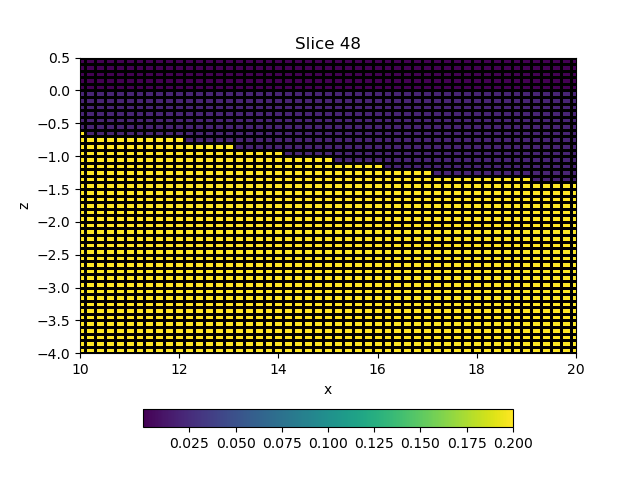

In [124]:
fig, ax = plt.subplots()

f0 = mesh.plot_slice(Model.property_x,
               normal = 'Y',
               v_type='CC',
               clim=[1e-6,0.2],
               ax=ax,
               grid=True)
ax.set_xlim([10,20])
ax.set_ylim([-4,0.5])
#ax.scatter(src_coords[0], src_coords[2], c='r', marker = '*')
#ax.scatter(rec_coords[0], rec_coords[1]+height, c='y')

fig.colorbar(f0[0], ax=ax, orientation='horizontal', fraction=0.05, norm='log')

In [5]:
# 5. Simulate data

def Dualem842_3D(xsrc, Model, Model_air, frequency=frequency, height=height):
   # print('Position:', p)
    print('Defining geometry')
    # Define source coordinates
    src_x = xsrc
    Hsrc_coords = [src_x, 0, height, 0, 90]
    Vsrc_coords = [src_x, 0, height, 90, 0]
    print('source:', Hsrc_coords)
    
    # Define H and V receivers coordinates
    offsets_HV = np.array([src_x+2, src_x+4, src_x+8])
    #print('offsets:',offsets_HV)
    #rec_coords = [offsets_HV, offsets_HV*0, np.ones_like(offsets_HV)*height, azi, dip]
    
    # Define P receivers coordinates
    offsets_P = np.array([src_x+2.1, src_x+4.1, src_x+8.1])
    #rec_coords_p = [offsets_P, offsets_P*0, np.ones_like(offsets_P)*height, azi, dip]
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsrc_coords)
    Vsource = emg3d.TxMagneticPoint(Vsrc_coords)
    
    # Solve Electrical fields
    #print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = Model, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = Model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = Model, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = Model_air, source = Vsource, frequency = frequency)

    # Get magnetic fields
   # print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = Model, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = Model, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_V_p)
    
    # Get fields at receivers
  #  print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec = Hfield_H.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec_p = Hfield_H_p.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec_s = H_Hrec - H_Hrec_p
    
    # For total field Vsource
    H_Vrec = Hfield_V.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec_p = Hfield_V_p.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec_s = H_Vrec - H_Vrec_p
    
    # For total field Psource
    H_Prec = Hfield_H.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec_p_xz = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec_s = H_Prec - H_Prec_p_xz
    # Primary field Psource in zz direction
    H_Prec_p = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 90))*(2j * np.pi * frequency * mu_0)
    
     # Calculate output components OP and IP
 #   print('getting output components')
    # Horizontal coplanar
    op_h = (H_Hrec_s/H_Hrec_p).imag.amp()
    ip_h = (H_Hrec_s/H_Hrec_p).real.amp()
    #OUT.append([op_h, ip_h])
    # Vertical coplanar
    op_v = (H_Vrec_s/H_Vrec_p).imag.amp()
    ip_v = (H_Vrec_s/H_Vrec_p).real.amp()
    #OUT.append([op_v, ip_v])
    # Perpendicular
    op_p = (H_Prec_s/H_Prec_p).imag.amp()
    ip_p = (H_Prec_s/H_Prec_p).real.amp()
    #OUT.append([op_p, ip_p])
    
 #   OUT_i = pd.DataFrame({'geom'  : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
 #                         'src_x' : [Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0],
 #                                    Vsrc_coords[0], Vsrc_coords[0], Vsrc_coords[0],
 #                                    Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0]],
 #                         'rec_x' : np.hstack((offsets_HV, offsets_HV, offsets_P)),
 #                         'midpx' : np.hstack((Hsrc_coords[0] + (offsets_HV - Hsrc_coords[0])/2,
 #                                              Vsrc_coords[0] + (offsets_HV - Vsrc_coords[0])/2,
 #                                              Hsrc_coords[0] + (offsets_P - Hsrc_coords[0])/2)),
 #                         'op'    : np.hstack((op_h, op_v, op_p)),
 #                         'ip'    : np.hstack((ip_h, ip_v, ip_p)) 
 #                         })
    
    #OUT = pd.concat([OUT, OUT_i], ignore_index=True)
    print()
    return np.array([op_h, op_p, op_v, ip_h, ip_p, ip_v]).ravel()
                 


# Routine

In [4]:
# 0. Define instrument settings

height = 0.15
frequency = 9000
n_workers = 20

# Define angles to test

alpha = np.arange(0,10)
alphasr = np.deg2rad(alpha)

sigmas = np.array([[20/1000, 200/1000],
                   [20/1000, 400/1000],
                   [20/1000, 800/1000],
                   [20/1000, 1600/1000]])

In [6]:
def ForwardDippingBoundary(alpha, sigmas):
    print('Running: alpha: ', np.degrees(alpha), 'sigma1: ', sigmas[0]*1000, 'sigma2: ', sigmas[1]*1000)
    
    xsrc = 11 # at 11 meters, since the center of the dipping boundary is at 15 m
    mdp = xsrc + 4
    
    pos = np.arange(0,30)
    h1 = np.ones_like(pos, dtype=float)
    h1[:mdp] = h1[:mdp] - np.flip(pos[:mdp]) * np.tan(alpha)
    h1[mdp-1:] = h1[mdp-1:] + pos[:mdp+1]* np.tan(alpha)
    
    # 1. Create a 2D model
    
    s1 = np.ones_like(h1)*sigmas[0]/1000
    s2 = np.ones_like(h1)*sigmas[1]/1000
    model = np.vstack((h1,s1,s2)).T
    npos = np.shape(model)[0]      # number of positions
    nlay = np.shape(model)[1] - 1  # number of layers
    
    depths = np.zeros((npos, nlay))
    depths[:,1] = - model[:,0]
    
    # 2. Create a mesh
    
    # Define a homogoneous model
    sig = np.array([100/1000])
    thk = np.array([])
    
    # Insert air layer
    sig_3d = np.hstack(([1/1e6], sig))
    depth_3d = np.hstack(([0], -np.cumsum(thk)))
    
    # mesh
    mesh = emg3d.construct_mesh(frequency = frequency,
                             properties = [20/1000, 20/1000, sig_3d[0]],
                             center = [mdp,0,height],
                             mapping='Conductivity',
                             domain = ([xsrc-10, xsrc+18],[-10, 10],[-10,10]),
                             min_width_limits = [0.2, 0.2, 0.1], # changed z from 0.1 to 0.2
                             center_on_edge=False,
                             stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                             lambda_from_center=True,
                             lambda_factor=3, 
                       #      cell_numbers=[512, 128, 128]
                       #      max_buffer = 300000,
                       #      min_width_pps = 5
                             )
    
    # 3. Populate mesh
    
    # Define air layer
    sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
    sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array

    x = mesh.cell_centers[:,0] <=0
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[0,0]) & (mesh.cell_centers[:,2] > depths[0,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[0,1]) 
    
    sig_x[x*y*z_lay1] = model[0,1] # First layer sigma
    sig_x[x*y*z_lay2] = model[0,2] # Second layer sigma
    
    for p in range(npos):
       
        x = (mesh.cell_centers[:,0] >= p) & (mesh.cell_centers[:,0] < p+1)
        y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
        z_lay1 = (mesh.cell_centers[:,2] < depths[p,0]) & (mesh.cell_centers[:,2] > depths[p,1])
        z_lay2 = (mesh.cell_centers[:,2] < depths[p,1]) 
    
        sig_x[x*y*z_lay1] = model[p,1]
        sig_x[x*y*z_lay2] = model[p,2]
    
    # fill after position npos
    
    x = (mesh.cell_centers[:,0] > npos) 
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[-1,0]) & (mesh.cell_centers[:,2] > depths[-1,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[-1,1]) 
    
    sig_x[x*y*z_lay1] = model[-1,1]
    sig_x[x*y*z_lay2] = model[-1,2]
    
    #  4. Define models
    
    Model = emg3d.Model(mesh, 
                     property_x = sig_x,
                     mapping = 'Conductivity')
    
    Model_air = emg3d.Model(mesh,
                         property_x = sig_air,
                         mapping = 'Conductivity')

    data = Dualem842_3D(xsrc, Model, Model_air)

    return data



In [7]:
ForwardDippingBoundary(alphasr[0], sigmas[0])

Running: alpha:  0.0 sigma1:  20.0 sigma2:  200.0
Defining geometry
source: [11, 0, 0.15, 0, 90]



,geom,src_x,rec_x,midpx,op,ip
0,H2,11,13.0,12.00,0.000010,6.948241e-06
1,H4,11,15.0,13.00,0.000050,1.824430e-05
2,H8,11,19.0,15.00,0.000203,4.848355e-05
3,V2,11,13.0,12.00,0.000009,2.709825e-07
4,V4,11,15.0,13.00,0.000056,2.077438e-06
5,V8,11,19.0,15.00,0.000309,1.430734e-05
6,P2,11,13.1,12.05,0.000005,9.688771e-09
7,P4,11,15.1,13.05,0.000032,4.222734e-08
8,P8,11,19.1,15.05,0.000163,7.689639e-08


In [ ]:
startTime = time.time()

OUT = Parallel(n_jobs=n_workers,verbose=0)(delayed(ForwardDippingBoundary)(ai, si) for ai in alphasr for si in sigmas)    

print()
endTime = time.time()
print('Done in', (endTime - startTime), 'seconds!')

#OUT_dataframe = pd.concat(OUT)

np.save('DippingBoundary/dataUR', OUT)
#OUT_dataframe.to_pickle('DippingBoundary/data.pkl')